In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 
pd.set_option('display.precision', 18)

In [2]:
be_1po = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_1Po.csv')
be_1po = be_1po.drop(columns = ['SO1', 'SO2'])
be_1po = be_1po.rename(columns= {'Basis Size': 'basis size'})
be_1po_inf = be_1po.loc[be_1po['basis size'] == max(be_1po['basis size'])]
be_1po_init = be_1po.iloc[:-1]

In [3]:
li_2po = upload_df('/home/aldiyar/extrapolation/large-dataset/Li_2Po.csv')
li_2po = li_2po.drop(columns = ['SO1', 'SO2'])
li_2po = li_2po.rename(columns= {'Basis Size': 'basis size'})
li_2po_inf = li_2po.loc[li_2po['basis size'] == max(li_2po['basis size'])]
li_2po_init = li_2po.iloc[:-1]

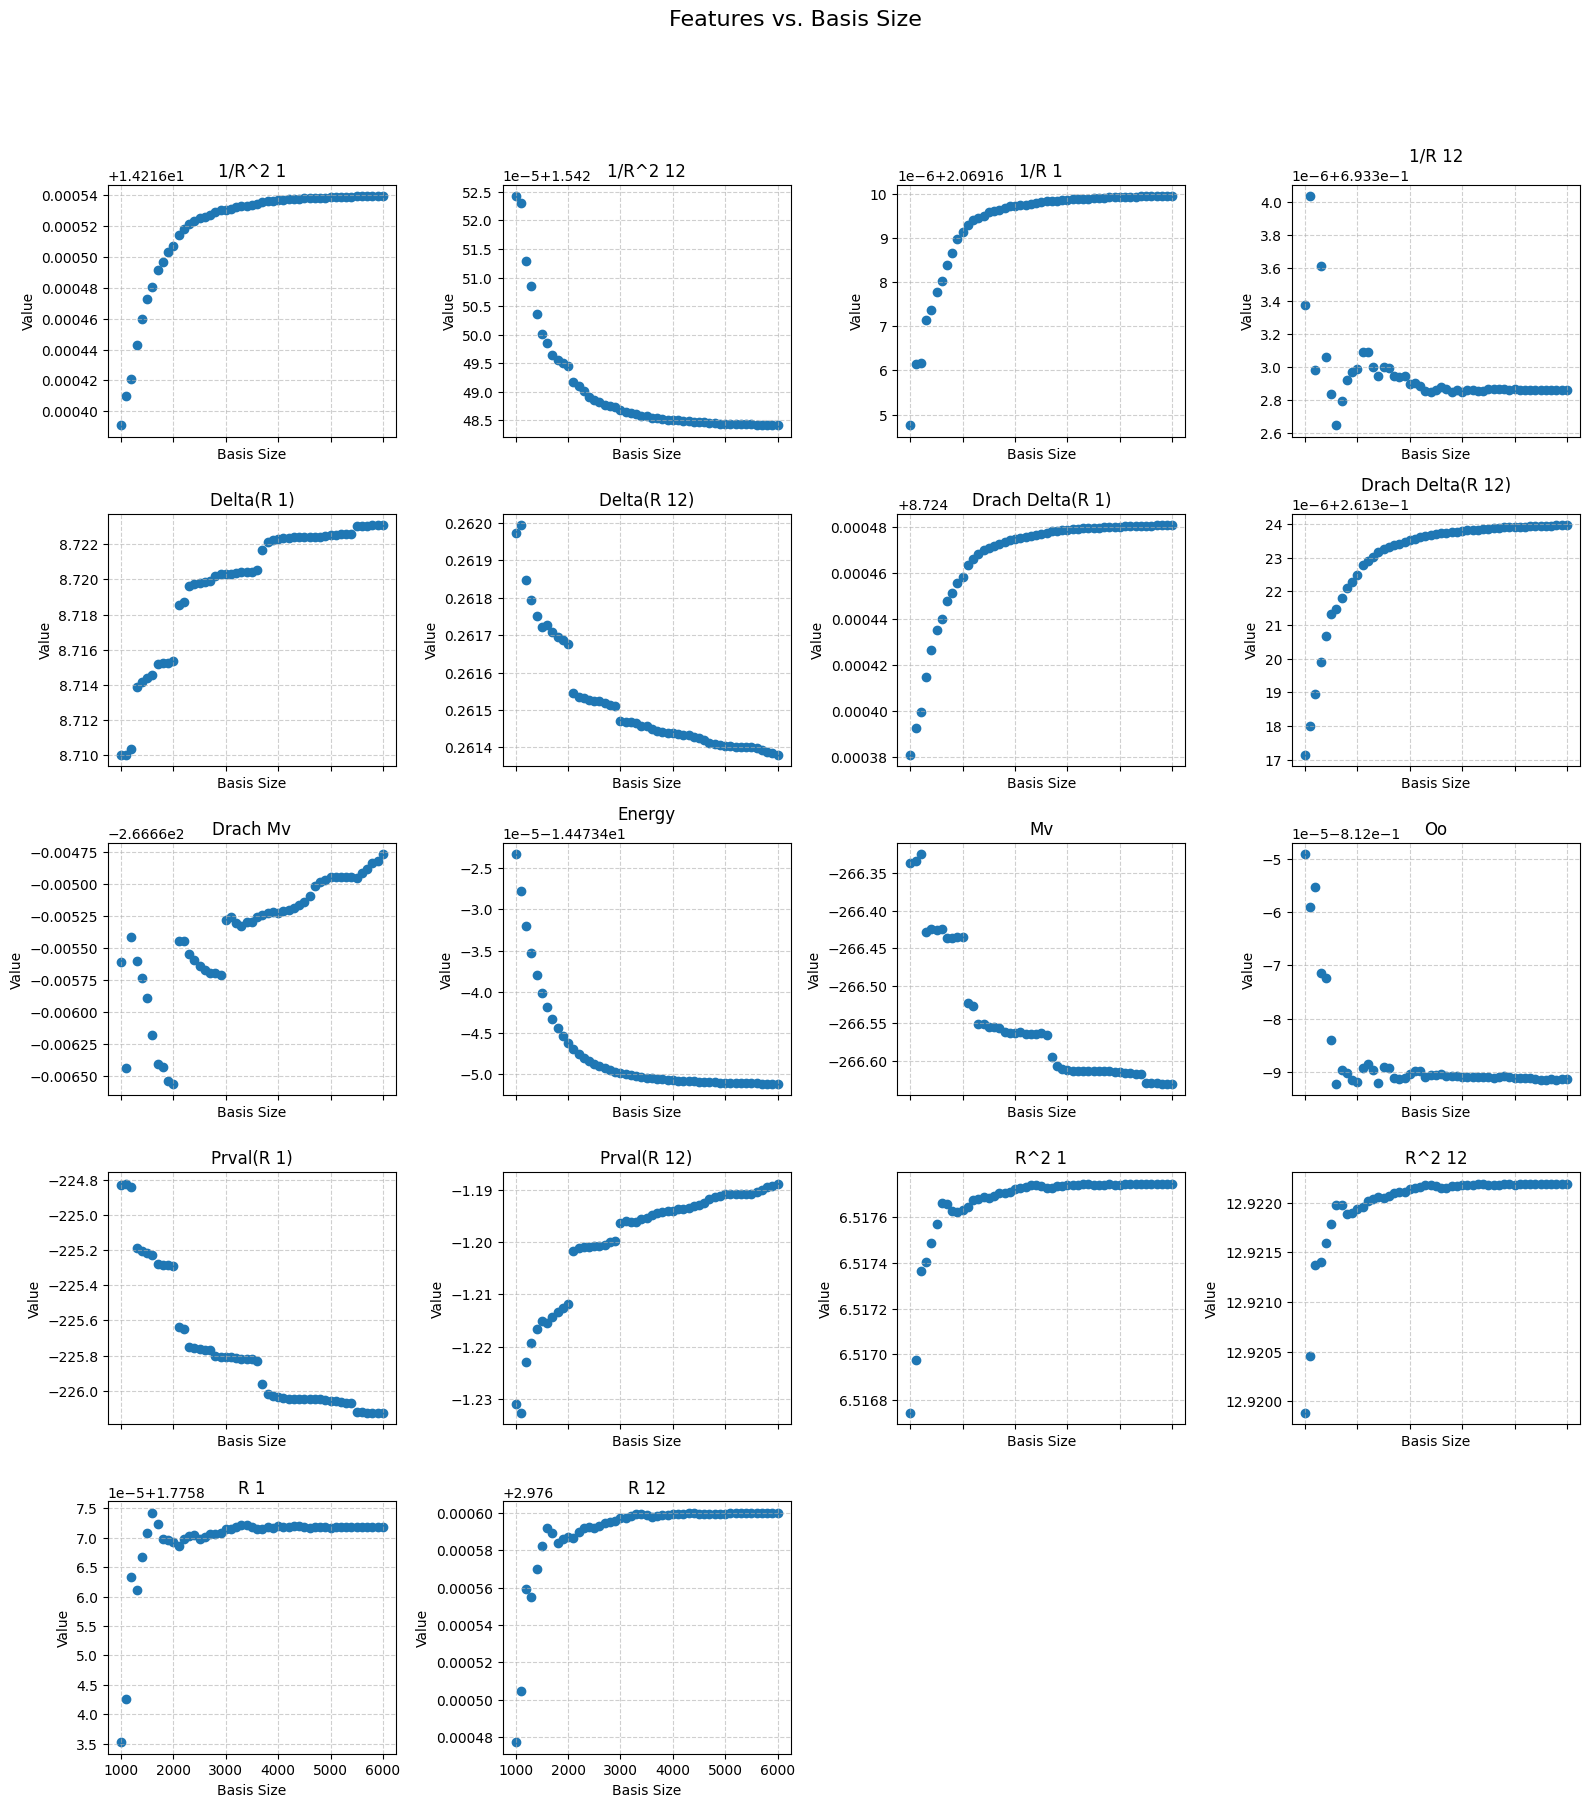

In [10]:
graph(be_1po_init)

In [31]:
from scipy.optimize import least_squares, lsq_linear

class VarProIRLS:
    def __init__(self, df, x_col, y_col, err_df=None, b_init=None):
        self.raw_x = df[x_col].values.astype(float)
        self.raw_y = df[y_col].values.astype(float)
        self.x_col = x_col
        self.y_col = y_col
        self.err_df = err_df 
        
        # Sort data by X
        idx = np.argsort(self.raw_x)
        self.raw_x = self.raw_x[idx]
        self.raw_y = self.raw_y[idx]

        self.x_min = self.raw_x.min()
        self.x_max = self.raw_x.max()
        self.range_x = self.x_max - self.x_min
        if self.range_x == 0: 
            self.range_x = 1.0
        
     
        slope, _ = np.polyfit(self.raw_x, self.raw_y, 1)
        self.is_increasing = slope > 0
        # --------------------------------

        self.override_b_init = b_init
        self.b_init = 1.0
        self.results = {}

    def _setup_model(self, model_type):
        self.model_type = model_type
        if self.model_type in ['power_law', 'sqrt_exponential']:
            safe_x = np.maximum(self.raw_x, self.x_max * 1e-6)
            self.t_scaled = safe_x / self.x_max
        else:
            self.t_scaled = (self.raw_x - self.x_min) / self.range_x
            
        if self.override_b_init is not None:
            self.b_init = self.override_b_init
        else:
            self.b_init = self._grid_search_initialization()

    def _get_A_bounds(self):
      
        if self.is_increasing:
            lb = [-np.inf, -np.inf]
            ub = [np.inf, 0]
        else: 
            lb = [-np.inf, 0]
            ub = [np.inf, np.inf]
        return lb, ub

    def _grid_search_initialization(self):
        grid_B = np.linspace(1, 100, 10000) 
        best_ssr = np.inf
        best_B = 1.0
        
        lb, ub = self._get_A_bounds()
        
        for b_val in grid_B: 
            phi = self._compute_basis(b_val, self.t_scaled)
            
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.inf
            
            if ssr < best_ssr:
                best_ssr = ssr
                best_B = b_val
                
        return best_B

    def _compute_basis(self, B, t):
        phi = np.zeros((len(t), 2))
        phi[:, 0] = 1.0
        if self.model_type == 'exponential':
            phi[:, 1] = np.exp(-B * t)
        elif self.model_type == 'sqrt_exponential':
            phi[:, 1] = np.exp(-B * np.sqrt(t))
        elif self.model_type == 'power_law': 
            phi[:, 1] = np.power(t, -B)
        return phi

    def _compute_model_weights(self, B, t):
        # Calculate raw components first
        if self.model_type == 'exponential':
            # Instead of exp(B*t), we use exp(B*t - max_exponent) to prevent overflow 
            # while maintaining relative ratios.
            # However, simpler approach: compute normally, handle inf, then normalize.
            
            # Since B*t can be large, calculating exp(B*t) directly risks overflow.
            # We can compute log weights first, normalize by subtracting max, then exp.
            log_w = B * t
        elif self.model_type == 'sqrt_exponential': 
            log_w = B * np.sqrt(t)
        elif self.model_type == 'power_law': 
            t_safe = np.maximum(t, 1e-12)
            # w = t^B -> log(w) = B * log(t)
            log_w = B * np.log(t_safe)
        
        # Multiply by 2 because we want w^2 (inverse variance approximation)
        # weight ~ (1/deriv)^2 ~ (1/exp(-Bt))^2 ~ exp(2Bt)
        log_w = 2.0 * log_w
        
        # Robust normalization in log-space to prevent overflow:
        # w_norm = exp(log_w - max(log_w))
        # This guarantees the largest weight is exactly 1.0
        max_log_w = np.max(log_w)
        normalized_w = np.exp(log_w - max_log_w)
        
        return normalized_w

    def _solve_varpro_step(self, weights, start_b=None):
        y_w = self.raw_y * np.sqrt(weights)
        if start_b is None:  
            start_b = self.b_init
        
        lb, ub = self._get_A_bounds()

        def residual_func(alpha_curr):
            phi = self._compute_basis(alpha_curr[0], self.t_scaled)
            phi_w = phi * np.sqrt(weights)[:, np.newaxis]
            res_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
            y_model = np.dot(phi, res_lin.x)
            return (self.raw_y - y_model) * np.sqrt(weights)

        res_opt = least_squares(residual_func, x0=[start_b], bounds=(1e-6, np.inf), 
                                method='trf', loss='soft_l1')
        
        best_B = res_opt.x[0]
        phi = self._compute_basis(best_B, self.t_scaled)
        phi_w = phi * np.sqrt(weights)[:, np.newaxis]
        final_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
        
        return best_B, final_lin.x[0], final_lin.x[1]

    def fit_irls(self, max_iter=100, tol=1e-8, damping=0.5, models=None, verbose=True, compute_uq=True):
        if models is None: 
            models = ['exponential', 'sqrt_exponential', 'power_law']
        
        for model in models: 
            self._setup_model(model)
            if verbose:
                print(f"\n--- Fitting Model: {self.model_type} ---")
                print(f"{'Iter':<5} | {'B (Decay)':<12} | {'C (Asymptote)':<15} | {'Weight Ratio':<25}")
                print("-" * 65)

            current_weights = np.ones(len(self.raw_x))
            prev_C = np.inf
            current_B_guess = self.b_init
            
            final_B, final_C, final_A = 0, 0, 0

            for k in range(max_iter):
                B, C, A = self._solve_varpro_step(current_weights, start_b=current_B_guess)
                current_B_guess = B
                final_B, final_C, final_A = B, C, A

                if abs(C - prev_C) < tol and k > 0:
                    if verbose:
                        print("-" * 65)
                        print(f"Converged at iteration {k}")
                    break
                prev_C = C

                new_weights = self._compute_model_weights(B, self.t_scaled)

                
                current_weights = (1 - damping) * current_weights + damping * new_weights
                print(f'current weights: {current_weights}')
                
                if verbose: 
                    # Ratio of max weight (1.0) to min weight
                    w_ratio = 1.0 / (np.min(current_weights) + 1e-12)
                    print(f"{k: <5} | {B:<12.6f} | {C: <15.6f} | {w_ratio:<25.2f}")

            phi = self._compute_basis(final_B, self.t_scaled)
            y_pred = final_C + final_A * phi[:, 1]
            ssr = np.sum((self.raw_y - y_pred)**2)
            
            dof = max(1, len(self.raw_y) - 1)
            sigma_noise = np.sqrt(ssr / dof)

            self.results[model] = {
                'B': final_B, 'C': final_C, 'A': final_A, 
                'ssr': ssr, 't_scaled': self.t_scaled.copy(),
                'sigma_noise': sigma_noise,
                'y_pred': y_pred,
                'final_weights': current_weights
            }
        
        if compute_uq and len(self.results) > 0:
            self.estimate_monte_carlo_uncertainty()
            
        return self.results

    def estimate_monte_carlo_uncertainty(self, n_samples=30):
        for model_name, res in self.results.items():
            y_pred = res['y_pred']
            sigma_noise = res['sigma_noise']
            warm_start_b = res['B']
            final_weights = res['final_weights']
            
            mc_Cs = []
            
            w_max = np.max(final_weights)
            if w_max == 0:
                 noise_scale_factors = np.ones_like(final_weights)
            else:
                 noise_scale_factors = final_weights / w_max
            
            for i in range(n_samples):
                base_noise = np.random.normal(0, sigma_noise, size=len(y_pred))
                weighted_noise = base_noise * noise_scale_factors
                y_synthetic = y_pred + weighted_noise
                
                sub_df = pd.DataFrame({self.x_col: self.raw_x, self.y_col: y_synthetic})
                sub_solver = VarProIRLS(sub_df, self.x_col, self.y_col, b_init=warm_start_b)
                
                sub_solver.fit_irls(models=[model_name], verbose=False, compute_uq=False)
                
                if model_name in sub_solver.results:
                    mc_Cs.append(sub_solver.results[model_name]['C'])
            
            # Using simple std dev as fallback logic is removed per visual instruction implication
            # sticking to pure std dev.
            sigma_robust = np.std(mc_Cs)
                
            self.results[model_name]['sigma_mc'] = sigma_robust

    def plot(self, truth_val=None):
        if not self.results: 
            return
        
        plt.figure(figsize=(12, 7))
        plt.plot(self.raw_x, self.raw_y, 'ko', label='Data', zorder=5, markersize=6)
        
        colors = {'exponential': 'blue', 'sqrt_exponential': 'orange', 'power_law': 'green'}
        labels = {'exponential': 'Exp($e^{-Bx}$)', 'sqrt_exponential': 'SqrtExp($e^{-B\\sqrt{x}}$)', 'power_law': 'Power($x^{-B}$)'}
        
        print("\n" + "="*80)
        print(f"{'Model':<20} | {'C (Asymptote)':<15} | {'MC Uncertainty':<20} | {'Diff from Truth'}")
        print("="*80)

        for model, res in self.results.items():
            C = res['C']
            sigma = res.get('sigma_mc', 0.0)
            
            diff_str = "-"
            if truth_val is not None:
                diff_str = f"{abs(C - truth_val):.2e}"
            
            print(f"{model:<20} | {C:<15.9f} | {sigma:<20.2e} | {diff_str}")
            
            x_plot = np.linspace(self.x_min, self.x_max * 1.5, 200)
            
            if model in ['power_law', 'sqrt_exponential']: 
                t_plot = x_plot / self.x_max
            else: 
                t_plot = (x_plot - self.x_min) / self.range_x
            
            self.model_type = model
            phi_plot = self._compute_basis(res['B'], t_plot)
            y_plot = C + res['A'] * phi_plot[:, 1]
            
            plt.plot(x_plot, y_plot, '-', color=colors[model], linewidth=2, alpha=0.8, label=f"{labels[model]}")
            
            plt.fill_between([self.x_min, self.x_max * 1.5], 
                             C - sigma, C + sigma, 
                             color=colors[model], alpha=0.1)
            
            plt.axhline(C, color=colors[model], linestyle='--', alpha=0.3)

        if truth_val is not None: 
            plt.axhline(truth_val, color='r', linestyle=':', linewidth=2, label=f'Truth ({truth_val:.8f})')
            
            if self.err_df is not None and self.y_col in self.err_df.columns:
                try:
                    truth_err = self.err_df[self.y_col].values[-1]
                    plt.fill_between([self.x_min, self.x_max * 1.5], 
                                     truth_val - truth_err, truth_val + truth_err, 
                                     color='r', alpha=0.15, zorder=0,
                                     label=f'Truth Error (±{truth_err:.1e})')
                except IndexError:
                    print(f"Warning: Could not extract error from {self.y_col} column.")
        
        plt.title(f"{self.y_col}")
        plt.xlabel("Basis Size")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_ssr_profile(self, model_type='exponential', b_range=(0.1, 20), num_points=200):
        self._setup_model(model_type)
        b_grid = np.linspace(b_range[0], b_range[1], num_points)
        ssr_values = []
        lb, ub = self._get_A_bounds()
        for b_val in b_grid:
            phi = self._compute_basis(b_val, self.t_scaled)
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.nan
            ssr_values.append(ssr)

        plt.figure(figsize=(10, 6))
        plt.plot(b_grid, ssr_values, label=f'SSR Profile ({model_type})', color='purple')
        if model_type in self.results:
            opt_b = self.results[model_type]['B']
            opt_ssr = self.results[model_type]['ssr']
            plt.plot(opt_b, opt_ssr, 'r*', markersize=15, label=f'Final Solution (B={opt_b:.3f})')
        plt.title(f"SSR Landscape vs Parameter B ({model_type})")
        plt.xlabel("B (Decay Rate)")
        plt.ylabel("Sum of Squared Residuals (SSR)")
        plt.yscale('log')
        plt.grid(True, which="both", ls="-", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


--- Fitting Model: exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
current weights: [0.50000001 0.50000001 0.50000002 0.50000003 0.50000004 0.50000005
 0.50000007 0.50000011 0.50000015 0.50000022 0.50000031 0.50000045
 0.50000064 0.50000091 0.5000013  0.50000186 0.50000266 0.5000038
 0.50000543 0.50000775 0.50001108 0.50001584 0.50002265 0.50003237
 0.50004627 0.50006613 0.50009453 0.50013511 0.50019313 0.50027605
 0.50039457 0.50056399 0.50080615 0.50115227 0.50164701 0.50235418
 0.50336497 0.50480976 0.50687489 0.5098267  0.5140459  0.52007667
 0.52869682 0.54101812 0.55862972 0.58380306 0.61978485 0.67121583
 0.74472929 0.84980658 1.        ]
0     | 8.930693     | -14.473451      | 2.00                     
current weights: [0.25000001 0.25000002 0.25000003 0.25000004 0.25000005 0.25000008
 0.25000011 0.25000016 0.25000023 0.25000033 0.25000047 0.25000067
 0.25000095 0.25000136 0.2

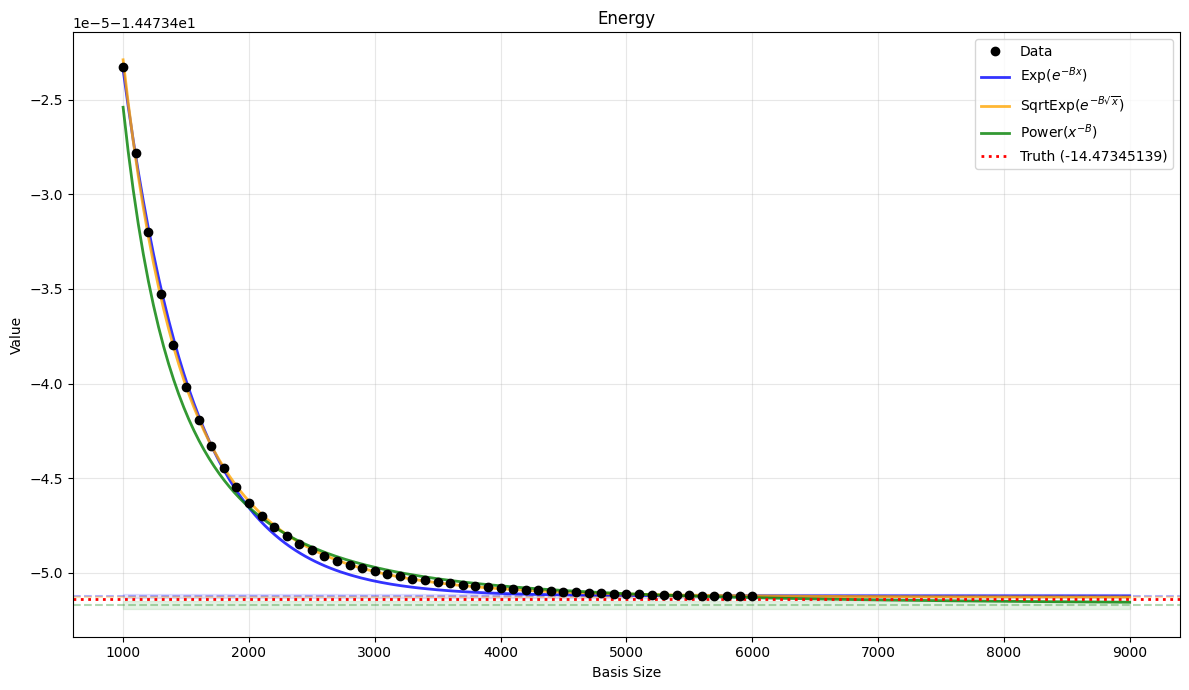

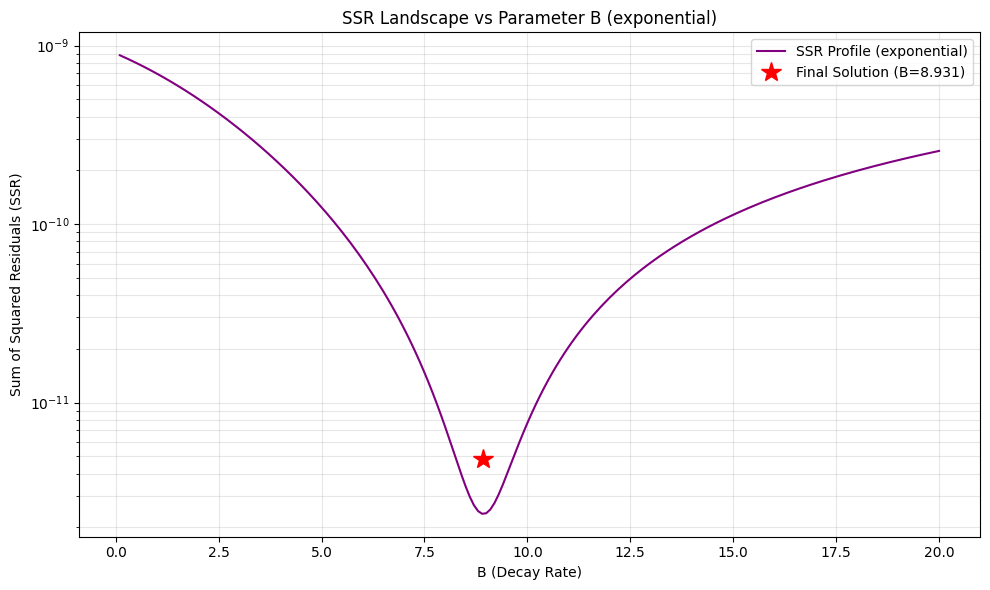

In [30]:
solver = VarProIRLS(be_1po_init, 'basis size', 'Energy')
solver.fit_irls()
solver.plot(truth_val =-14.473451386869200519)
solver.plot_ssr_profile()

In [5]:
be_1po_inf

,basis size,Energy,MV,drach_MV,OO,1/r^2_1,1/r^2_12,1/r_1,1/r_12,r_1,r_12,r^2_1,r^2_12,delta(r_1),delta(r_12),drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12)
60,16400,-14.473451386869200519,-266.659088807117996112,-266.664462793425002474,-0.812091476559140046,14.216540761971700135,1.542483736797960026,2.069169995852650157,0.693302859821317008,1.775871778505659915,2.976600188092250132,6.517748468239560111,12.922195769590199887,8.724265747607580224,0.261343940528712015,8.724481440729169535,0.261324032380949978,-226.280220458874993028,-1.185257894829250036
